# Projet Machine Learning : Prédiction du Risque de Maladie Cardiaque

## Auteur : [Votre Nom]
## Module : Machine Learning Appliqué
## Date : Juin 2026

# Partie 1 - Business Understanding

## Contexte médical

Les maladies cardiovasculaires sont l'une des principales causes de décès dans le monde. La détection précoce du risque de maladie cardiaque permet de mettre en place des mesures préventives adaptées et d'améliorer les chances de survie des patients.

## Problème à résoudre

L'objectif est de prédire si un patient présente un risque de maladie cardiaque en se basant sur des caractéristiques médicales simples comme l'âge, le sexe, la pression artérielle, le taux de cholestérol, et d'autres indicateurs cliniques.

## Pourquoi le Machine Learning est utile ?

Le Machine Learning permet d'analyser automatiquement les relations complexes entre les différentes variables médicales et d'établir des prédictions fiables. Contrairement aux méthodes traditionnelles basées sur des règles simples, les modèles de ML peuvent capturer des patterns non évidents dans les données et fournir des prédictions personnalisées pour chaque patient.

## Type de problème : Classification Binaire

Il s'agit d'un problème de **classification binaire** car nous devons prédire une variable cible qui ne peut prendre que deux valeurs :
- **0** : Absence de maladie cardiaque
- **1** : Présence ou risque de maladie cardiaque

## Variable cible

La variable cible est `target` :
- `target = 0` : Le patient ne présente pas de maladie cardiaque
- `target = 1` : Le patient présente un risque de maladie cardiaque

## Objectifs du projet

1. **Comprendre les données médicales disponibles** : Analyser la structure du dataset et les caractéristiques des patients.

2. **Identifier les variables importantes** : Déterminer quelles caractéristiques médicales sont les plus corrélées au risque cardiaque.

3. **Construire plusieurs modèles de classification** : Tester différents algorithmes de Machine Learning pour comparer leurs performances.

4. **Comparer les performances des modèles** : Évaluer les modèles avec des métriques appropriées (accuracy, precision, recall, F1-score).

5. **Déployer le meilleur modèle** : Créer une application web simple permettant de prédire le risque cardiaque pour un nouveau patient.

# Partie 2 - Data Understanding

## Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour l'affichage des graphiques
%matplotlib inline
sns.set_style("whitegrid")

## Chargement du dataset

In [2]:
# Chargement du dataset
df = pd.read_csv("../data/heart.csv")

## Analyse exploratoire des données

### Affichage des premières lignes

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


**Interprétation :** Cette commande affiche les 5 premières lignes du dataset. Cela nous permet de voir la structure des données et les valeurs des différentes colonnes.

### Dimensions du dataset

In [4]:
df.shape

(1025, 14)

**Interprétation :** Le résultat indique le nombre de lignes (patients) et de colonnes (variables) dans le dataset.

### Informations sur les types de données

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


**Interprétation :** Cette commande affiche le type de chaque colonne (entier, flottant, etc.) et le nombre de valeurs non nulles. C'est important pour vérifier qu'il n'y a pas de valeurs manquantes.

### Statistiques descriptives

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


**Interprétation :** Ce tableau résume les statistiques principales pour chaque variable numérique : moyenne, écart-type, minimum, maximum, et les quartiles. Cela nous donne une vue d'ensemble de la distribution des données.

### Vérification des valeurs manquantes

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

**Interprétation :** Cette commande compte le nombre de valeurs manquantes (NaN) dans chaque colonne. Si le résultat est 0 pour toutes les colonnes, cela signifie qu'il n'y a pas de données manquantes.

### Vérification des doublons

In [8]:
df.duplicated().sum()

np.int64(723)

**Interprétation :** Cette commande compte le nombre de lignes dupliquées dans le dataset. Si des doublons sont présents, ils devront être supprimés pour éviter de biaiser l'entraînement des modèles.

### Répartition de la variable cible

In [9]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

**Interprétation :** Cette commande affiche le nombre de patients dans chaque classe (0 et 1). Il est important de vérifier si les classes sont équilibrées. Si une classe est beaucoup plus représentée que l'autre, cela peut impacter les performances des modèles.

## Description des colonnes du dataset

Voici la signification des principales variables du dataset :

- **age** : Âge du patient en années
- **sex** : Sexe du patient (0 = femme, 1 = homme)
- **cp** : Type de douleur thoracique (0-4)
  - 0 : Angine typique
  - 1 : Angine atypique
  - 2 : Douleur non angineuse
  - 3 : Asymptomatique
- **trestbps** : Pression artérielle au repos (en mm Hg)
- **chol** : Taux de cholestérol sérique (en mg/dl)
- **fbs** : Taux de sucre dans le sang à jeun (0 = ≤ 120 mg/dl, 1 = > 120 mg/dl)
- **restecg** : Résultats électrocardiographiques au repos (0-2)
  - 0 : Normal
  - 1 : Anomalie ST-T
  - 2 : Hypertrophie ventriculaire
- **thalach** : Fréquence cardiaque maximale atteinte
- **exang** : Angine induite par l'exercice (0 = non, 1 = oui)
- **oldpeak** : Dépression ST induite par l'exercice par rapport au repos
- **slope** : Pente du segment ST à l'exercice (0-2)
  - 0 : Montante
  - 1 : Plate
  - 2 : Descendante
- **ca** : Nombre de vaisseaux majeurs colorés par fluoroscopie (0-3)
- **thal** : Résultat du test de thallium (0-3)
  - 0 : Normal
  - 1 : Défaut fixe
  - 2 : Défaut réversible
  - 3 : Non mesurable
- **target** : Variable cible (0 = absence de maladie cardiaque, 1 = présence de maladie cardiaque)

# Partie 3 - Data Visualization

## 1. Répartition de la variable cible

Ce graphique permet d'observer la répartition des patients selon la variable cible. Il est important de vérifier si les classes sont équilibrées avant l'entraînement des modèles.

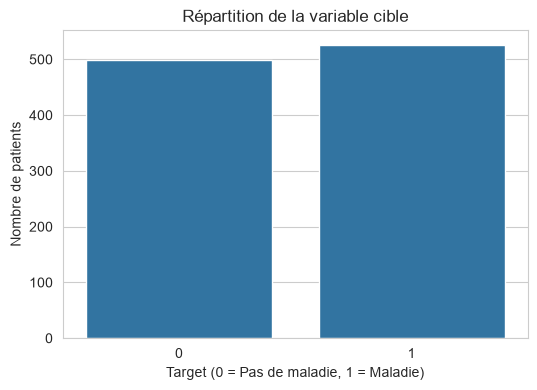

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Répartition de la variable cible")
plt.xlabel("Target (0 = Pas de maladie, 1 = Maladie)")
plt.ylabel("Nombre de patients")
plt.show()

**Interprétation :** Ce graphique montre le nombre de patients dans chaque classe. Si les deux barres ont des hauteurs similaires, les classes sont équilibrées. Si une classe est beaucoup plus représentée, il faudra peut-être utiliser des techniques pour gérer ce déséquilibre.

## 2. Distribution de l'âge des patients

Ce graphique montre la distribution de l'âge des patients dans le dataset. Cela permet de comprendre la tranche d'âge représentée et d'identifier si les données sont concentrées autour d'une moyenne ou si elles sont dispersées.

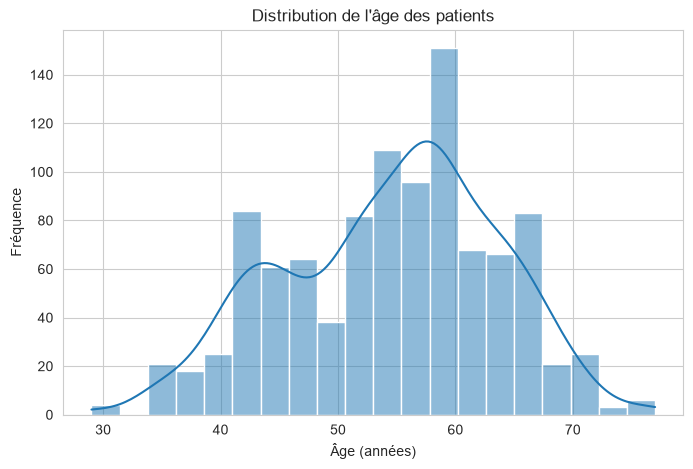

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], kde=True, bins=20)
plt.title("Distribution de l'âge des patients")
plt.xlabel("Âge (années)")
plt.ylabel("Fréquence")
plt.show()

**Interprétation :** L'histogramme avec la courbe de densité (KDE) montre la distribution des âges. On peut observer la tranche d'âge la plus représentée et si la distribution est symétrique ou asymétrique. Cela nous donne une idée de la population étudiée.

## 3. Relation entre l'âge et la variable cible

Ce graphique permet de voir si l'âge influence le risque de maladie cardiaque. On compare la distribution des âges pour les patients avec et sans maladie cardiaque.

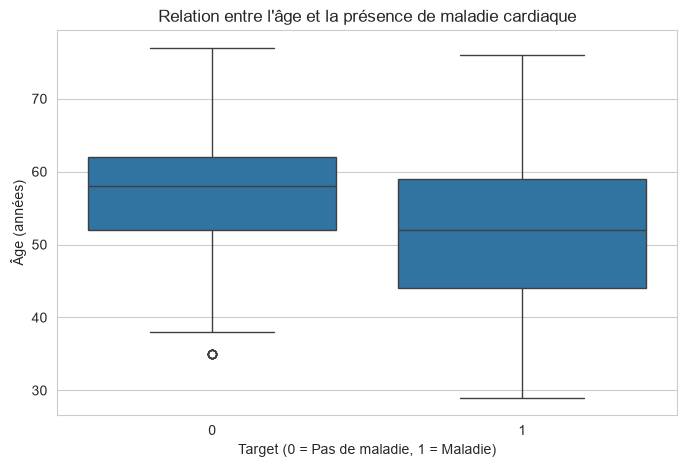

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="age", data=df)
plt.title("Relation entre l'âge et la présence de maladie cardiaque")
plt.xlabel("Target (0 = Pas de maladie, 1 = Maladie)")
plt.ylabel("Âge (années)")
plt.show()

**Interprétation :** Le boxplot permet de comparer la distribution des âges entre les deux classes. Si les boîtes sont à des niveaux différents, cela indique que l'âge a une influence sur le risque de maladie cardiaque.

## 4. Matrice de corrélation

La matrice de corrélation permet d'identifier les relations entre les différentes variables. Les valeurs proches de 1 indiquent une forte corrélation positive, les valeurs proches de -1 indiquent une forte corrélation négative, et les valeurs proches de 0 indiquent une absence de corrélation.

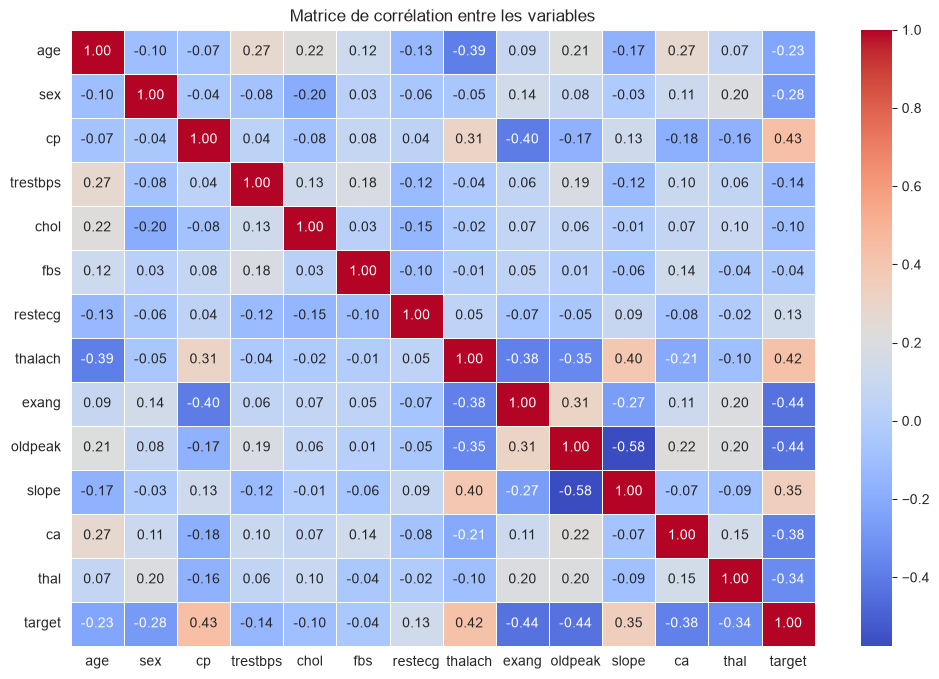

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation entre les variables")
plt.show()

**Interprétation :** Cette matrice permet d'identifier les variables les plus corrélées avec la variable cible `target`. Les variables avec une corrélation forte (positive ou négative) sont potentiellement importantes pour la prédiction. On peut aussi détecter des corrélations entre variables explicatives, ce qui peut indiquer une multicolinéarité.

## 5. Comparaison de variables importantes selon la classe target

Nous allons maintenant comparer la distribution de quelques variables clés selon que le patient a ou non une maladie cardiaque.

### 5.1. Fréquence cardiaque maximale (thalach) selon target

La fréquence cardiaque maximale atteinte lors d'un test d'effort peut être un indicateur important de la santé cardiaque.

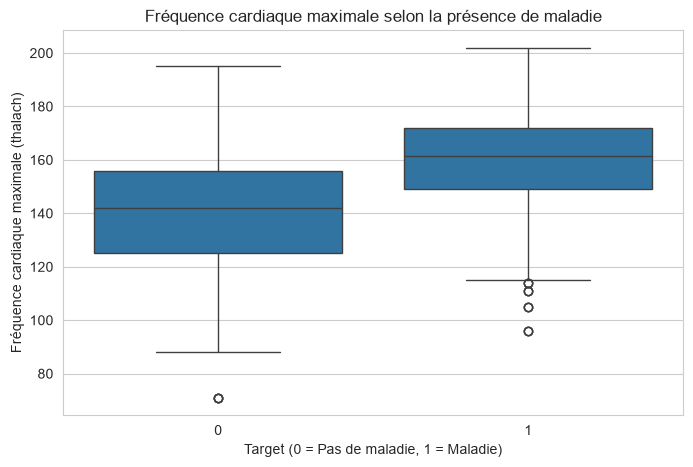

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="thalach", data=df)
plt.title("Fréquence cardiaque maximale selon la présence de maladie")
plt.xlabel("Target (0 = Pas de maladie, 1 = Maladie)")
plt.ylabel("Fréquence cardiaque maximale (thalach)")
plt.show()

**Interprétation :** Ce graphique compare la fréquence cardiaque maximale entre les patients avec et sans maladie cardiaque. Une différence notable entre les deux groupes suggère que cette variable est pertinente pour la prédiction.

### 5.2. Taux de cholestérol (chol) selon target

Le taux de cholestérol est un facteur de risque connu pour les maladies cardiovasculaires. Nous allons observer sa distribution selon la classe target.

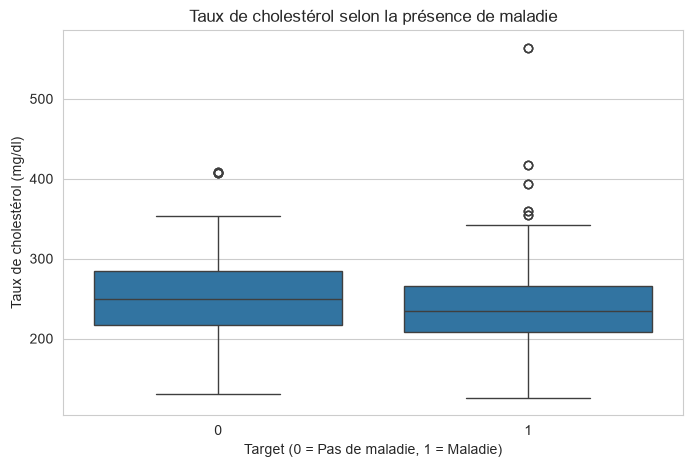

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="chol", data=df)
plt.title("Taux de cholestérol selon la présence de maladie")
plt.xlabel("Target (0 = Pas de maladie, 1 = Maladie)")
plt.ylabel("Taux de cholestérol (mg/dl)")
plt.show()

**Interprétation :** Ce graphique permet de voir si le taux de cholestérol diffère significativement entre les patients avec et sans maladie cardiaque. Si la différence est marquée, le cholestérol sera une variable importante pour le modèle.

### 5.3. Type de douleur thoracique (cp) selon target

Le type de douleur thoracique est un indicateur clinique important. Nous allons observer sa répartition selon la classe target.

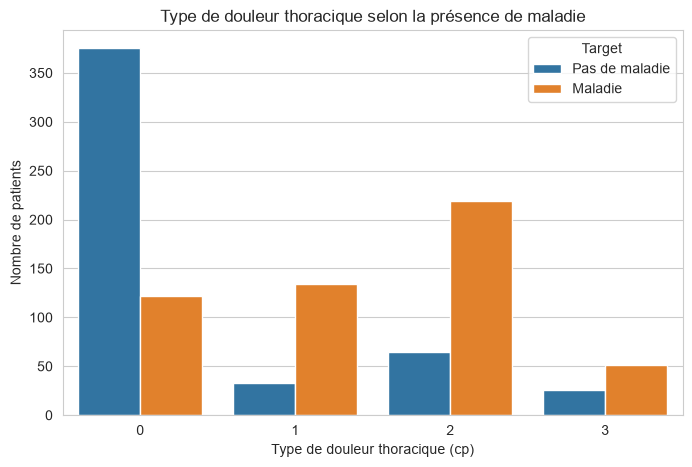

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x="cp", hue="target", data=df)
plt.title("Type de douleur thoracique selon la présence de maladie")
plt.xlabel("Type de douleur thoracique (cp)")
plt.ylabel("Nombre de patients")
plt.legend(title="Target", labels=["Pas de maladie", "Maladie"])
plt.show()

**Interprétation :** Ce graphique montre la répartition des types de douleur thoracique pour chaque classe. Certains types de douleur peuvent être plus associés à la présence de maladie cardiaque que d'autres.

### 5.4. Sexe (sex) selon target

Le sexe du patient peut être un facteur de risque. Nous allons observer la répartition des hommes et des femmes selon la classe target.

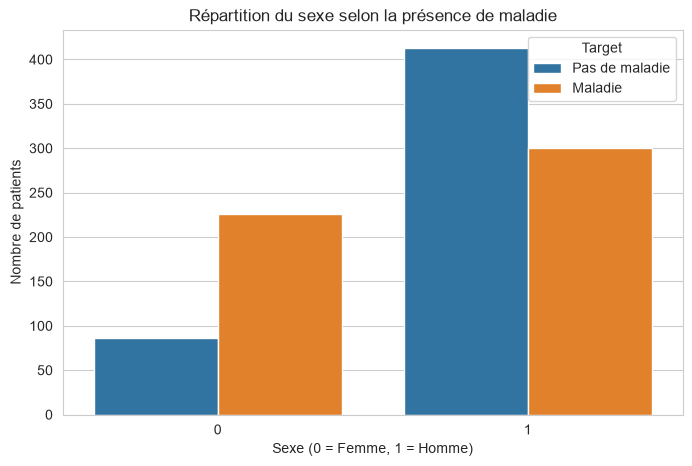

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x="sex", hue="target", data=df)
plt.title("Répartition du sexe selon la présence de maladie")
plt.xlabel("Sexe (0 = Femme, 1 = Homme)")
plt.ylabel("Nombre de patients")
plt.legend(title="Target", labels=["Pas de maladie", "Maladie"])
plt.show()

**Interprétation :** Ce graphique montre la répartition des hommes et des femmes selon la présence ou non de maladie cardiaque. Cela permet de voir si le sexe influence le risque de maladie cardiaque dans ce dataset.

# Partie 4 - Data Preparation

## 1. Vérification des valeurs manquantes

Nous vérifions s'il y a des valeurs manquantes dans le dataset. Si des valeurs sont manquantes, il faudrait les imputer ou supprimer les lignes correspondantes.

In [18]:
df_clean.isnull().sum()

NameError: name 'df_clean' is not defined

**Interprétation :** Si le résultat est 0 pour toutes les colonnes, cela signifie qu'il n'y a aucune valeur manquante dans le dataset. Dans ce cas, aucune imputation n'est nécessaire.

## 2. Vérification et suppression des doublons

Les doublons peuvent biaiser l'entraînement des modèles en donnant plus de poids à certaines observations. Nous allons les détecter et les supprimer si nécessaire.

In [ ]:
# Vérification du nombre de doublons
nb_doublons = df_clean.duplicated().sum()
print(f"Nombre de doublons : {nb_doublons}")

# Suppression des doublons si présents
if nb_doublons > 0:
    df_clean = df_clean.drop_duplicates()
    print("Doublons supprimés.")
else:
    df_clean = df_clean.copy()
    print("Aucun doublon détecté.")

In [ ]:
# Vérification de la nouvelle taille du dataset
df_clean.shape

**Interprétation :** Après suppression des doublons, nous avons un dataset nettoyé. La nouvelle forme du dataset est affichée ci-dessus.

## 3. Séparation des variables explicatives et de la variable cible

Nous séparons le dataset en deux parties :
- **X** : les variables explicatives (caractéristiques médicales) utilisées pour la prédiction
- **y** : la variable cible (target) que nous voulons prédire

La variable cible `target` a deux valeurs :
- `0` : absence de maladie cardiaque
- `1` : présence ou risque de maladie cardiaque

In [ ]:
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

In [ ]:
# Vérification des dimensions
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

## 4. Division des données en train/test

Nous divisons les données en deux ensembles :
- **Train** : pour entraîner les modèles (80% des données)
- **Test** : pour évaluer les performances (20% des données)

**Pourquoi cette division ?**
- Cela permet d'évaluer la capacité du modèle à généraliser sur des données qu'il n'a jamais vues
- `test_size=0.2` signifie que 20% des données sont réservées pour le test
- `random_state=42` assure la reproductibilité des résultats (le même split à chaque exécution)
- `stratify=y` garantit que la proportion des classes (0 et 1) est conservée dans les deux ensembles, ce qui est important pour éviter un biais dans l'évaluation

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

## 5. Normalisation des données

La normalisation (standardisation) met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1). 

**Pourquoi est-ce important ?**
- Certains modèles comme Logistic Regression, KNN et SVM sont sensibles à l'échelle des variables
- Sans normalisation, les variables avec de grandes valeurs (ex: cholestérol) auraient plus d'influence que celles avec de petites valeurs (ex: sexe)
- La normalisation améliore la convergence et les performances de ces modèles

**Méthode :**
- `fit_transform` sur les données d'entraînement : calcule la moyenne et l'écart-type, puis applique la transformation
- `transform` sur les données de test : applique uniquement la transformation en utilisant les paramètres calculés sur le train
- Cela évite la "fuite de données" (data leakage) en n'utilisant aucune information du test pour la normalisation

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Vérification des données normalisées
print("Exemple de données normalisées (X_train_scaled) :")
print(X_train_scaled[:5])

## 6. Conclusion de la préparation des données

Les données sont maintenant prêtes pour la phase de modélisation. Nous disposons de :
- Un jeu d'entraînement (X_train, y_train) pour entraîner les modèles
- Un jeu de test (X_test, y_test) pour évaluer les performances
- Des versions normalisées des variables explicatives (X_train_scaled, X_test_scaled) pour les modèles sensibles à l'échelle

Le scaler a été entraîné sur les données d'entraînement et sera sauvegardé pour être utilisé dans l'application Flask.

# Partie 5 - Modeling

## 1. Importation des modèles

Nous allons importer quatre algorithmes de classification différents pour comparer leurs performances.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

## 2. Présentation des modèles

Voici une brève description des quatre modèles que nous allons utiliser :

- **Logistic Regression** : Modèle linéaire simple et interprétable. Il calcule la probabilité qu'une observation appartienne à une classe en utilisant une fonction sigmoïde. C'est souvent utilisé comme modèle de référence (baseline) pour la classification binaire.

- **Random Forest** : Modèle d'ensemble basé sur plusieurs arbres de décision. Chaque arbre est entraîné sur un sous-ensemble différent des données et des variables. Les prédictions sont agrégées par vote majoritaire. Ce modèle est robuste et capable de capturer des relations non linéaires complexes.

- **K-Nearest Neighbors (KNN)** : Modèle basé sur la proximité entre les observations. Pour prédire la classe d'une nouvelle observation, il regarde les K observations les plus proches dans l'espace des caractéristiques et attribue la classe majoritaire. C'est un modèle simple et intuitif.

- **Support Vector Machine (SVM)** : Modèle qui cherche à trouver la frontière optimale (hyperplan) séparant les deux classes. Il maximise la marge entre les classes, ce qui le rend robuste pour les problèmes de classification. Le noyau RBF (Radial Basis Function) permet de gérer des relations non linéaires.

## 3. Création du dictionnaire de modèles

Nous créons un dictionnaire contenant les quatre modèles avec leurs hyperparamètres de base.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42)
}

## 4. Entraînement des modèles

Nous allons entraîner chaque modèle sur les données d'entraînement normalisées. Les modèles apprendront les relations entre les variables médicales et la présence de maladie cardiaque.

In [ ]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} entraîné avec succès.")

## 5. Vérification simple des prédictions

Nous vérifions rapidement que les modèles fonctionnent correctement en affichant quelques prédictions du premier modèle (Logistic Regression) et en les comparant aux vraies valeurs.

In [ ]:
sample_predictions = trained_models["Logistic Regression"].predict(X_test_scaled[:5])
print("Exemples de prédictions :", sample_predictions)
print("Vraies valeurs :", y_test.iloc[:5].values)

## 6. Conclusion de la partie Modeling

Les quatre modèles ont été entraînés avec succès sur les données d'entraînement normalisées. Chaque modèle a appris les relations entre les variables médicales et la présence de maladie cardiaque.

L'étape suivante consiste à évaluer leurs performances sur les données de test en utilisant différentes métriques (accuracy, precision, recall, F1-score) afin de choisir le meilleur modèle pour le déploiement.

# Partie 6 - Evaluation

## 1. Importation des métriques d'évaluation

Nous allons utiliser plusieurs métriques pour évaluer les performances des modèles :

- **Accuracy** : Proportion totale de prédictions correctes. C'est la métrique la plus simple mais elle peut être trompeuse si les classes sont déséquilibrées.

- **Precision** : Parmi les patients prédits comme étant à risque (classe 1), proportion qui est réellement à risque. Une precision élevée signifie peu de faux positifs.

- **Recall** : Parmi tous les patients réellement à risque (classe 1), proportion qui a été correctement détectée par le modèle. Un recall élevé signifie peu de faux négatifs.

- **F1-score** : Moyenne harmonique entre precision et recall. C'est une métrique équilibrée qui prend en compte à la fois les faux positifs et les faux négatifs.

- **Confusion Matrix** : Tableau qui montre le nombre de vrais positifs, vrais négatifs, faux positifs et faux négatifs.

**Pourquoi ne pas regarder seulement l'accuracy ?**
Dans un problème médical comme celui-ci, il est crucial de bien détecter les patients à risque. Un modèle pourrait avoir une accuracy élevée en prédisant toujours "pas de maladie" si la majorité des patients sont sains, mais il serait inutile car il ne détecterait aucun patient à risque. C'est pourquoi nous devons aussi regarder le recall et le F1-score.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

## 2. Évaluation de chaque modèle

Nous allons maintenant évaluer chaque modèle sur les données de test en calculant les différentes métriques et en affichant les matrices de confusion et les rapports de classification.

In [ ]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    print("=" * 60)
    print(f"Modèle : {name}")
    print("=" * 60)
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report :")
    print(classification_report(y_test, y_pred))

## 3. Tableau comparatif des modèles

Nous créons un DataFrame pour comparer facilement les performances des différents modèles. Les résultats sont triés par F1-score décroissant pour identifier le meilleur modèle.

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-score", ascending=False)
results_df

**Interprétation du tableau comparatif :**

Ce tableau permet de comparer les performances des quatre modèles sur les différentes métriques. Nous pouvons observer :

- Le modèle avec la meilleure **accuracy** est celui qui a le plus grand pourcentage de prédictions correctes globales.
- Le modèle avec le meilleur **recall** est celui qui détecte le mieux les patients réellement à risque (moins de faux négatifs).
- Le modèle avec le meilleur **F1-score** est celui qui offre le meilleur équilibre entre precision et recall.

**Pourquoi le F1-score est utilisé pour choisir le meilleur modèle ?**

Dans un contexte médical, le F1-score est particulièrement pertinent car :
- Il pénalise à la fois les faux positifs (patients sains prédits comme malades) et les faux négatifs (patients malades prédits comme sains)
- Il offre un meilleur équilibre que l'accuracy lorsque les classes sont légèrement déséquilibrées
- Il permet de choisir un modèle qui performe bien sur les deux aspects importants : ne pas manquer de patients à risque (recall) et ne pas alarmer inutilement les patients sains (precision)

## 4. Visualisation comparative des performances

Ce graphique permet de visualiser et comparer facilement les performances des différents modèles sur les quatre métriques principales.

In [ ]:
plt.figure(figsize=(10, 6))
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Comparaison des performances des modèles")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interprétation du graphique :** Ce graphique en barres permet de comparer visuellement les performances des modèles. Les barres plus hautes indiquent de meilleures performances. On peut observer quel modèle est le plus performant globalement et s'il y a des modèles qui excellent sur certaines métriques mais pas sur d'autres.

## 5. Matrice de confusion du meilleur modèle

Nous sélectionnons automatiquement le meilleur modèle selon le F1-score et affichons sa matrice de confusion sous forme graphique pour visualiser ses performances de manière plus intuitive.

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Meilleur modèle :", best_model_name)

In [ ]:
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Matrice de confusion - {best_model_name}")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

**Interprétation de la matrice de confusion :**

La matrice de confusion affiche :
- **En haut à gauche (Vrai Négatif)** : Nombre de patients sans maladie correctement prédits comme sains
- **En haut à droite (Faux Positif)** : Nombre de patients sans maladie incorrectement prédits comme malades
- **En bas à gauche (Faux Négatif)** : Nombre de patients malades incorrectement prédits comme sains
- **En bas à droite (Vrai Positif)** : Nombre de patients malades correctement prédits comme malades

Dans un contexte médical, les faux négatifs sont particulièrement problématiques car ils correspondent à des patients malades qui ne sont pas détectés par le modèle.

## 6. Conclusion de l'évaluation

Après comparaison des différents modèles sur les données de test, le modèle retenu est celui qui présente le meilleur F1-score. Ce choix est pertinent car le F1-score permet de trouver un équilibre entre la précision et le rappel, ce qui est particulièrement important dans un contexte médical.

Le modèle sélectionné est identifié dans la cellule précédente (variable `best_model_name`). Ce modèle offre les meilleures performances globales et sera sauvegardé pour être utilisé dans l'application Flask de déploiement.

# Partie 7 — Sauvegarde du meilleur modèle

Dans cette partie, nous sauvegardons le meilleur modèle sélectionné lors de l’évaluation ainsi que le scaler utilisé pour la normalisation.

Ces deux fichiers seront ensuite utilisés dans l’application web Flask pour effectuer des prédictions à partir des données saisies par l’utilisateur.

In [ ]:
import joblib
import os

current_dir = os.getcwd()
print("Dossier de travail actuel :", current_dir)

if os.path.basename(current_dir) == "notebook":
    app_dir = os.path.abspath("../app")
else:
    app_dir = os.path.abspath("app")

model_path = os.path.join(app_dir, "model.pkl")
scaler_path = os.path.join(app_dir, "scaler.pkl")

print("Dossier app utilisé :", app_dir)
print("Chemin model.pkl :", model_path)
print("Chemin scaler.pkl :", scaler_path)

In [ ]:
os.makedirs(app_dir, exist_ok=True)

print("Dossier app créé ou confirmé :", app_dir)

In [ ]:
joblib.dump(best_model, model_path)

print(f"Meilleur modèle sauvegardé : {best_model_name}")
print("Chemin du modèle :", model_path)

In [ ]:
joblib.dump(scaler, scaler_path)

print("Scaler sauvegardé avec succès.")
print("Chemin du scaler :", scaler_path)

In [ ]:
print("model.pkl existe :", os.path.exists(model_path))
print("scaler.pkl existe :", os.path.exists(scaler_path))
print("Contenu du dossier app :", os.listdir(app_dir))

## Explication de l’utilité des fichiers sauvegardés

- `model.pkl` contient le meilleur modèle entraîné. Il sera chargé par l’application Flask pour effectuer des prédictions.
- `scaler.pkl` contient le scaler utilisé pour normaliser les données pendant l’entraînement.

Il est important d’utiliser le même scaler pendant l’entraînement et pendant la prédiction afin de garantir la cohérence des données. Si les nouvelles données saisies dans le formulaire ne sont pas normalisées de la même manière que les données d’entraînement, les prédictions peuvent être incorrectes.

La sauvegarde de ces deux fichiers permet donc de déployer le modèle dans une application web Flask.